<a href="https://colab.research.google.com/github/Jalilfatirunaanfasya/quality-inspection-dashboard/blob/main/quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Quality Inspection Data Analysis**

## 1. Data Overview
This section introduces the anonymized manufacturing quality inspection dataset, including supplier, machine, defect type, shift, and process variables used for analysis.

In [ ]:
import pandas as pd #Memanggil python dan memberi alias pd
df = pd.read_csv('quality_inspection_cleaned.csv', sep=';') #Membaca dan membuka file (data dipisahkan dengan koma)
df.head() #Menampilkan 5 baris pertama dari DataFrame untuk memastikan format data benar dan terbaca

,Date,Month,Year,Material Supplier,Product Code,Machine,Inspection Type,Defect Type,Defect Mode,Cause,Type of Cause,Number of Repairs,Inspector,Shift
0,24/10/2024,Oct,2024,Supplier_1,Product_23,Machine_C,In-process,Visual,SR,Material,Material Failures,1,Inspector_5,Morning_Shift
1,24/10/2024,Oct,2024,Supplier_1,Product_23,Machine_C,In-process,Visual,DT,Material,Material Failures,1,Inspector_5,Morning_Shift
2,24/10/2024,Oct,2024,Supplier_2,Product_6,Machine_D,First,Visual,SR,Mold,Dirty Mold,1,Inspector_10,Morning_Shift
3,24/10/2024,Oct,2024,Supplier_2,Product_6,Machine_D,First,Visual,DT,Mold,Dirty Mold,1,Inspector_10,Morning_Shift
4,24/10/2024,Oct,2024,Supplier_1,Product_23,Machine_C,In-process,Visual,DM,Machine,Setup and Adjustment Machine,6,Inspector_3,Afternoon_Shift


## 2. Defect Count Analysis

Answer:
* What are the most frequent defect types?

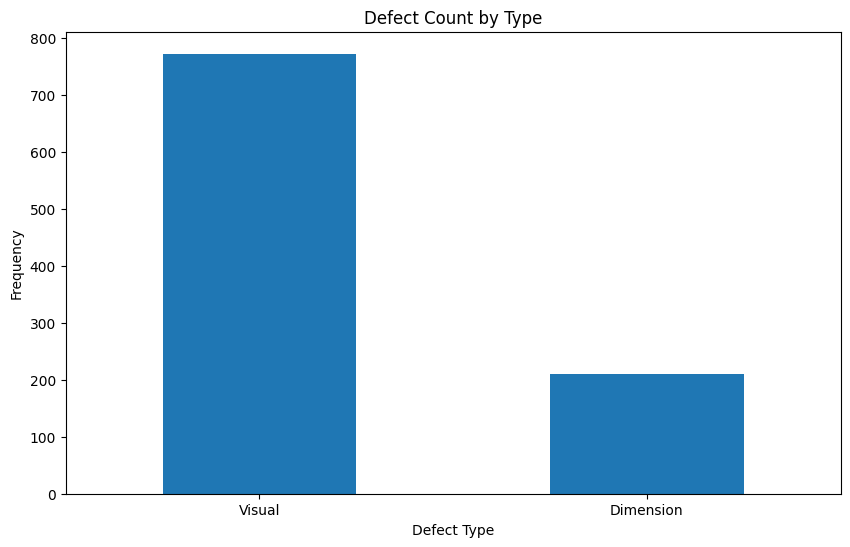

In [ ]:
import matplotlib.pyplot as plt  # Mengimpor library matplotlib untuk visualisasi data

plt.figure(figsize=(10,6))  # Membuat ukuran grafik dengan lebar 10 dan tinggi 6

df['Defect Type'].value_counts().plot(kind='bar')  # Menghitung jumlah tiap defect lalu membuat bar chart

plt.title("Defect Count by Type")  # Memberikan judul grafik

plt.xlabel("Defect Type")  # Label sumbu X

plt.ylabel("Frequency")  # Label sumbu Y

plt.xticks(rotation=0)  # Memiringkan teks pada sumbu X agar lebih mudah dibaca

plt.show()  # Menampilkan grafik


### Insight

**Visual defects are the dominant quality issue**, significantly exceeding Dimension-related defects. This indicates that surface appearance and visible process inconsistencies are the primary manufacturing challenges. Therefore, improvement efforts should prioritize visual inspection and corrective actions targeting the main contributors to visual failures for the greatest quality impact.

##3. Shift Performance Analysis
Answer:
* Which shift has the most defects?

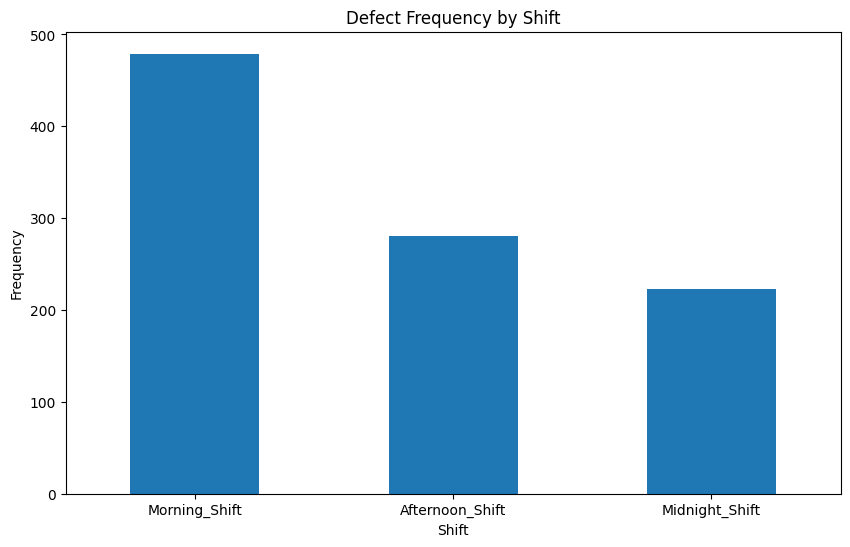

In [55]:
import matplotlib.pyplot as plt # Mengimpor library matplotlib untuk visualisasi data
plt.figure(figsize=(10,6)) # Membuat ukuran grafik dengan lebar 10 dan tinggi 6
df['Shift'].value_counts().plot(kind='bar')  # Menghitung jumlah tiap defect lalu membuat bar chart
plt.title("Defect Frequency by Shift") # Memberikan judul grafik
plt.xlabel("Shift").set_fontsize('medium')  # Label sumbu X
plt.ylabel("Frequency")  # Label sumbu Y
plt.xticks(rotation=0)  # Memiringkan teks pada sumbu X agar lebih mudah dibaca
plt.show()


###Insights

The shift performance analysis indicates that **the Morning Shift recorded the highest defect frequency** among all operational shifts.

## 4. Root Cause Analysis

Answer:
* Which root causes contribute most to overall defects, and where should improvement efforts be prioritized

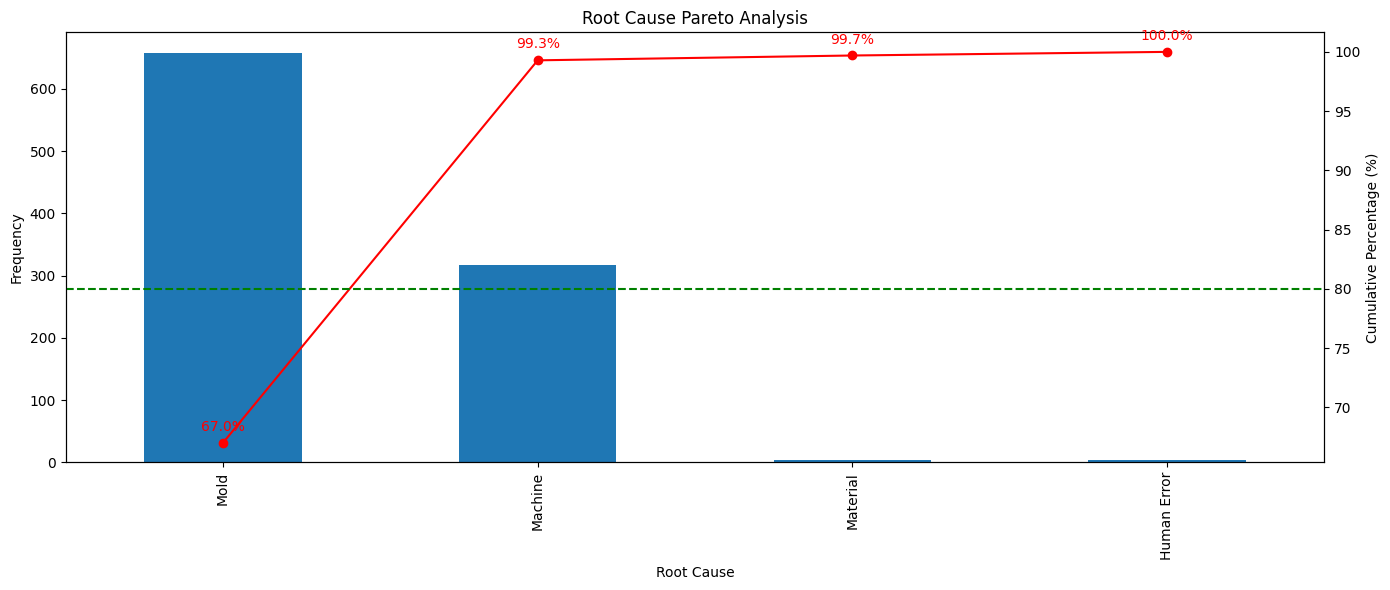

In [68]:
import matplotlib.pyplot as plt # Mengimpor library matplotlib untuk visualisasi data

root_counts = df['Cause'].value_counts() # Menghitung jumlah kemunculan setiap root cause
# cumsum() = menghitung total kumulatif bertahap
# root_counts.sum() = total seluruh defect
# Dibagi total lalu dikali 100 untuk mendapatkan persentase kumulatif
# Digunakan untuk Pareto line (80/20 analysis)
cumulative = root_counts.cumsum() / root_counts.sum() * 100

# Membuat figure/grafik baru
# figsize=(14,6) = ukuran grafik 14 inci x 6 inci
# ax1 = sumbu utama untuk bar chart
fig, ax1 = plt.subplots(figsize=(14,6))

# Membuat grafik batang berdasarkan jumlah tiap root cause
# ax=ax1 = menempatkan grafik pada sumbu utama
root_counts.plot(kind='bar', ax=ax1)
ax1.set_xlabel("Root Cause") # Memberi nama sumbu X
ax1.set_ylabel("Frequency") # Memberi nama sumbu Y kiri
ax1.set_title("Root Cause Pareto Analysis") # Memberikan judul grafik

ax2 = ax1.twinx()# Membuat sumbu Y kedua di sisi kanan
# Membuat garis kumulatif Pareto
# color='red' = garis merah
# marker='o' = titik lingkaran pada setiap data
ax2.plot(cumulative.values, color='red', marker='o')
# Label sumbu Y kanan
# Menunjukkan persentase kumulatif
ax2.set_ylabel("Cumulative Percentage (%)")
# Membuat garis horizontal pada level 80%
# Digunakan untuk prinsip Pareto (80/20 rule)
# Garis hijau putus-putus
ax2.axhline(80, color='green', linestyle='--')

# Add percentage labels
for i, value in enumerate(cumulative.values):
    # Loop setiap nilai cumulative percentage

    ax2.text(i, value + 1, f'{value:.1f}%', color='red', ha='center')
    # Menampilkan label persentase di atas tiap titik garis Pareto

plt.tight_layout() # Menyesuaikan tata letak agar label/judul tidak bertabrakan
plt.show()

### Insight

**Mold is the dominant root cause**, contributing approximately 67% of total defects, while **Machine accounts for around 31%**. Together, these two factors contribute nearly 98% of all quality issues, making them the primary sources of manufacturing defects. In contrast, Material and Human Error have minimal impact on overall defect frequency. Therefore, improvement efforts should primarily **focus on resolving mold-related and machine-related issues**, as addressing these two root causes offers the greatest opportunity for defect reduction.

## Conclusion


## Future Development
- Machine defect comparison
- Predictive quality modeling